In [4]:
%pip install networkx matplotlib pandas tqdm gcastle torch pgmpy ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [5]:
from castle.common import GraphDAG
from castle.datasets import IIDSimulation, DAG
import pandas as pd

# gera um DAG aleatório com pesos
weighted_random_dag = DAG.erdos_renyi(n_nodes=25, n_edges=100, weight_range=(0.5, 2.0), seed=1)

# gera um dataset a partir do DAG
dataset = IIDSimulation(W=weighted_random_dag, n=1000, method='linear', sem_type='gauss')
true_causal_matrix, X = dataset.B, dataset.X

df_X = pd.DataFrame(X, columns=[f'X{i}' for i in range(X.shape[1])])
df_X.head()

2026-04-23 11:48:39,218 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/datasets/simulator.py[line:270] - INFO: Finished synthetic dataset


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24
0,-2.127170,-1.197660,-25.242431,-13.653178,-0.642316,29.953199,-5.957807,1.872178,-0.318161,-1.963261,...,28.356799,-1.880971,-1.821577,-0.455215,-2.016061,0.961383,-0.780887,-80.879527,2.865039,13.113677
1,3.401325,14.530429,-20.998010,-4.784506,1.026511,-21.023388,4.334184,-0.755443,20.807048,-0.801215,...,-4.791658,6.642228,-0.705196,1.309543,-10.997460,5.449937,2.877823,-5.618771,3.219251,-35.398704
2,3.191765,12.773103,21.271310,15.730705,-0.333274,-40.580511,7.859874,1.594469,14.556948,-1.899005,...,-34.884777,2.503745,-1.101876,0.782277,-6.417553,4.211696,4.728689,97.432767,0.712502,-33.761943
3,2.675676,6.331725,-117.070799,-66.472882,0.303896,83.650332,-16.803270,-0.447381,10.294654,-0.732389,...,105.318201,-0.265290,-3.318117,1.714588,-20.366956,1.738037,-4.636923,-330.157900,2.709119,14.810448
4,-2.877817,-12.959274,31.804007,14.787331,0.190367,2.998709,-1.871484,0.272856,-19.849563,1.018615,...,-14.289958,-3.819264,1.213141,-0.351923,14.051908,-4.871824,-3.038927,54.348112,-2.660265,26.568294


Gerando grafo PC


2026-04-23 11:48:40,158 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=25, iter_=100, h_=1e-08, rho_=1e+16


Tempo de execução do PC: 0.015320916970570883 min 
Gerando grafo Notears


2026-04-23 11:48:40,596 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=9.510e-01, loss=42338.997, rho=1.0e+00
2026-04-23 11:48:40,779 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=6.261e-01, loss=14.228, rho=1.0e+00
2026-04-23 11:48:40,794 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=3.237e-01, loss=18.298, rho=1.0e+01
2026-04-23 11:48:41,369 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=1.258e-01, loss=58.997, rho=1.0e+02
2026-04-23 11:48:41,547 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 2] h=8.636e-02, loss=16

Tempo de execução do Notears: 1.7248516440391541 min 
Gerando grafo Genetic Discovery
Tempo de execução do Genetic Discovery: 5.829095832506815 min 


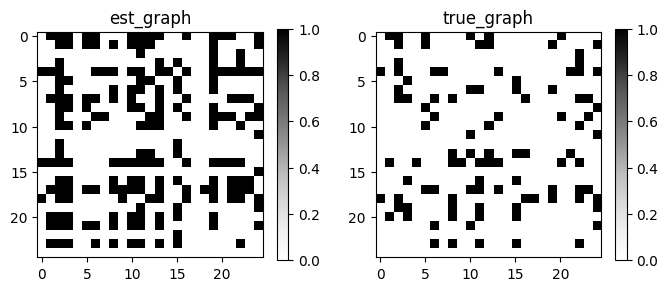

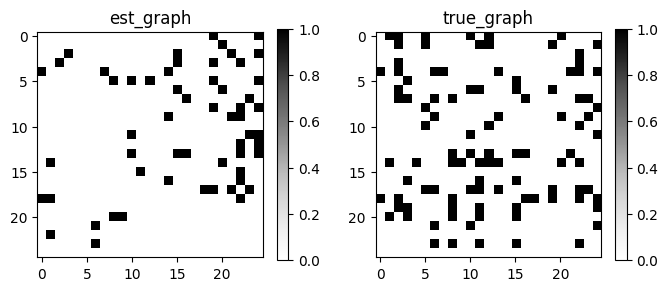

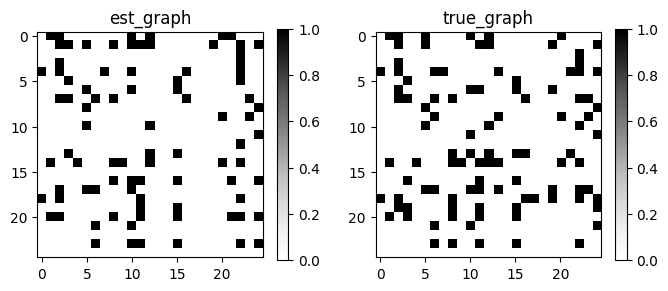

In [6]:
import time
from castle.algorithms import PC, Notears, GES
from genetic_discovery.main import genetic_discovery


print("Gerando grafo PC")
time_start = time.time()
pc = PC()
pc.learn(X)
time_end = time.time()
print(f"Tempo de execução do PC: {(time_end - time_start) / 60} min ")


print("Gerando grafo Notears")
time_start = time.time()
notears = Notears()
notears.learn(X)
time_end = time.time()
print(f"Tempo de execução do Notears: {(time_end - time_start) / 60} min ")

#print("Gerando grafo GES")
#time_start = time.time()
#ges = GES()
#ges.learn(X)
#time_end = time.time()
#print(f"Tempo de execução do GES: {(time_end - time_start) / 60} min ")

print("Gerando grafo Genetic Discovery")
time_start = time.time()
initial_population = [pc.causal_matrix, notears.causal_matrix] #, ges.causal_matrix]
pop_size = 500 
best_dag = genetic_discovery(X, n_nodes=pc.causal_matrix.shape[0], matrix_initial_pop=initial_population, num_generations=1000, population_size=pop_size, num_parents_mating=int(pop_size*0.5), mutation_rate=0.2)
time_end = time.time()
print(f"Tempo de execução do Genetic Discovery: {(time_end - time_start) / 60} min ")



GraphDAG(best_dag, true_causal_matrix, 'result')
GraphDAG(pc.causal_matrix, true_causal_matrix, 'result')
GraphDAG(notears.causal_matrix, true_causal_matrix, 'result')
#GraphDAG(ges.causal_matrix, true_causal_matrix, 'result')


In [7]:
from castle.metrics import MetricsDAG

print("Genetic DAG:")
metrics = MetricsDAG(true_causal_matrix, best_dag)
display(metrics.metrics)

print("PC DAG:")
metrics = MetricsDAG(true_causal_matrix, pc.causal_matrix)
display(metrics.metrics)

print("Notears DAG:")
metrics = MetricsDAG(true_causal_matrix, notears.causal_matrix)
display(metrics.metrics)

#print("GES DAG:")
#metrics = MetricsDAG(true_causal_matrix, ges.causal_matrix)
#display(metrics.metrics)

Genetic DAG:


{'fdr': 0.1089,
 'tpr': 0.4569,
 'fpr': 0.1068,
 'shd': 108,
 'nnz': 101,
 'precision': np.float64(0.8911),
 'recall': np.float64(0.4569),
 'F1': np.float64(0.604),
 'gscore': np.float64(0.401)}

PC DAG:


{'fdr': 0.7822,
 'tpr': 0.386,
 'fpr': 0.3251,
 'shd': 103,
 'nnz': 101,
 'precision': np.float64(0.2178),
 'recall': np.float64(0.386),
 'F1': np.float64(0.2785),
 'gscore': np.float64(0.0)}

Notears DAG:


{'fdr': 0.3663,
 'tpr': 0.7356,
 'fpr': 0.1737,
 'shd': 60,
 'nnz': 101,
 'precision': np.float64(0.6337),
 'recall': np.float64(0.7356),
 'F1': np.float64(0.6809),
 'gscore': np.float64(0.3103)}

In [8]:
import numpy as np
import pandas as pd
from castle.algorithms import PC, Notears, GES
from genetic_discovery.main import genetic_discovery

# Carrega o dataset real (CSV)
df_raw = pd.read_csv('cbio_imputado.csv')
df_num = df_raw.select_dtypes(include=[np.number]).copy()
df_num = df_num.dropna(axis=0).dropna(axis=1)

if df_num.shape[1] < 2:
    raise ValueError('O CSV precisa ter pelo menos 2 colunas numericas para descoberta causal.')

X_csv = df_num.to_numpy(dtype=float)
print(f'Dados carregados: {X_csv.shape[0]} amostras x {X_csv.shape[1]} variaveis')





Dados carregados: 2440 amostras x 30 variaveis


In [9]:
# printa os grafos 
GraphDAG(pc_csv.causal_matrix, None, 'PC')
GraphDAG(notears_csv.causal_matrix, None, 'Notears')
GraphDAG(best_dag_csv, None, 'Genetic Discovery')

NameError: name 'pc_csv' is not defined